In [2]:
import h5py
from functools import partial
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
import statsmodels.api as sm

from spikeparam.patch.fit import PolySpikeGroup

### PolySpikeGroup

`PolySpikeGroup` is a subclass of `SpikeGroup` that additionally computes a polynomial spline. The two API differences are that the former is initalized with an `orders` argument that determines the order per polynomial, and the `points` argument is used to define which points to compute polynomials between, defaulting to: 

```
['ramp_start', 'inflection', 'rise', 'peak', 'decay', 'tau', 'mtau', 'exp_end']
```

Polynomial coefficients are stored in `.df_poly` and `.poly_*` attributes, including:

`.poly_coeffs`
`.poly_fit`
`.poly_indices`
`.poly_order`
`.poly_rsqs`
`.poly_rsq_full`

In [3]:
# Load data
fs = 200000 

def reader(ind, alt=False):
    
    file = h5py.File('../pvc-6/153098.04.02_data.h5', 'r')
    dset = file['Sweep_' + str(ind)]
    
    if alt:
        sig = dset[:, 0]
    else:
        sig = dset[:, 1]
    
    return sig

In [4]:
# Fit
orders = [2, 2, 2, 2, 2, 2, 2]
psg = PolySpikeGroup(orders=orders, window_length=(4, 4))

psg.fit(np.arange(20), fs, reader=reader, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/99 [00:00<?, ?it/s]

PolySpike:   0%|          | 0/99 [00:00<?, ?it/s]

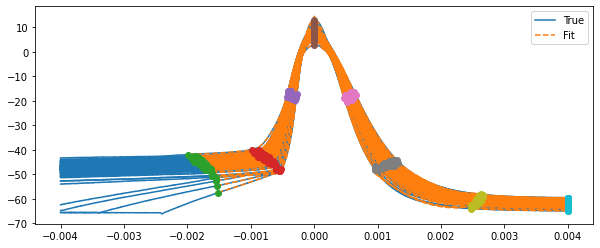

In [5]:
psg.plot()

### Simulation

Next, the polynomial and point indices distributions are used to randomly sampling a multivariate normal distribution. The sampled parameters are then used to simulate spikes with similar statistics and shape as the real data.

This works but there needs to be a better way to smooth the simulations at the edges of the polynomials so they are too disjointed.

In [6]:
from functools import partial
from scipy.optimize import curve_fit

def sim_ppoly(xs, inds, *coeffs, order=3):
    
    ys_fit = np.zeros(len(xs))

    if isinstance(order, int):
        order = np.tile(order, len(inds)-1)

    _coeffs = []
    pos = 0
    for i in order:
        _coeffs.append(coeffs[pos:pos+i+1])
        pos += i+1
    
    starts = inds[:-1]
    ends = inds[1:] + 1

    for i in range(len(starts)):

        _xs = xs[starts[i]:ends[i]]
        
        ys_fit[starts[i]:ends[i]] = np.poly1d(_coeffs[i])(_xs)
        
    return ys_fit


def _sim_ppoly(xs, *coeffs, inds=None, order=None):

    return sim_ppoly(xs, inds, *coeffs, order=order)


def fit(ys, inds, pad=10, sigma=.1):
    
    ys = ys[inds[0]:]
    xs = np.arange(len(ys))

    inds -= inds[0]

    n_params = sum([i + 1 for i in order])

    pfunc = partial(_sim_ppoly, inds=inds, order=order)
    
    _sigma = np.ones(len(ys))
    
    for ind in inds:
        pad_inds = np.arange(ind-pad, ind+pad+1)

        pad_inds = pad_inds[np.where(
            (pad_inds >= 0) &
            (pad_inds <= len(ys)-1)
        )[0]]

        _sigma[pad_inds] = sigma

    xs -= xs[inds[3]]
    
    params, _ = curve_fit(pfunc, xs, ys, p0=[0] * n_params, sigma=_sigma)
    
    return xs, ys, inds, params

In [7]:
order = [2, 2, 2, 2, 2, 2, 2]

spikes = psg.spikes.copy()
poly_inds = psg.poly_indices.copy()

n_params = sum([i+1 for i in order])

_params = np.zeros((len(spikes), n_params))
_inds = np.zeros((len(spikes), len(order)+1), dtype=int)

# Results
xs_true = []
ys_true = []

xs_fit = []
ys_fit = []

rsqs = np.zeros(len(spikes))

# Run
for ind in range(len(spikes)):
    
    xs, ys, _inds[ind], _params[ind] = fit(spikes[ind], poly_inds[ind], pad=10, sigma=.01)
    
    xs_true.append(xs)
    ys_true.append(ys)
    
    ys_fit.append(_sim_ppoly(xs_true[ind], *_params[ind], inds=_inds[ind], order=order))
    
    rsqs[ind] = np.corrcoef(ys, ys_fit[-1])[0][1]**2

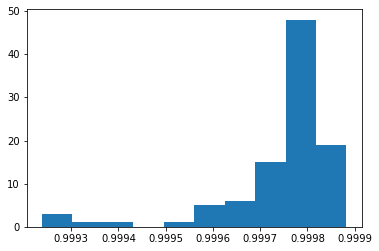

In [8]:
plt.hist(rsqs);

In [26]:
params = np.column_stack((_params, _inds))

params_mean = np.mean(params, axis=0)
params_cov = np.cov(params, rowvar=0)

params_cov = params_cov/2

n_sims = 100

ys_sim = []
xs_sim = []
inds_sim = []

for n in range(n_sims):
    
    params_sim = np.random.multivariate_normal(params_mean, params_cov)

    params_sim_poly = params_sim[:len(_params[0])]
    
    params_sim_inds = params_sim[len(_params[0]):].astype(int)
    params_sim_inds[0] = 0 if params_sim_inds[0] < 0 else params_sim_inds[0]
    
    inds_sim.append(params_sim_inds)
    
    xs = np.arange(params_sim_inds[-1]+1)
    xs -= xs[params_sim_inds[3]]
    
    
    _ys_sim = _sim_ppoly(xs, *params_sim_poly, inds=params_sim_inds, order=order)
    
    starts = params_sim_inds[:-1]
    ends = params_sim_inds[1:]
    
    for i in range(1, len(starts)):

        _ys_sim[starts[i]:ends[i]] = \
            _ys_sim[starts[i]:ends[i]] - (_ys_sim[starts[i]]-_ys_sim[ends[i-1]-1])
        
    ys_sim.append(_ys_sim)
    xs_sim.append(xs)

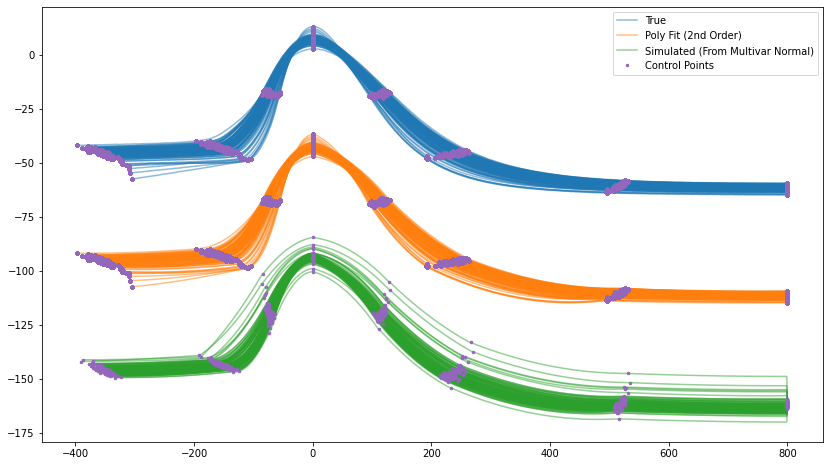

In [28]:
plt.figure(figsize=(14, 8))

has_lab = False
for x, y in zip(xs_true, ys_true):
    label = 'True' if not has_lab else ''
    plt.plot(x, y, color='C0', alpha=.5, label=label)
    has_lab = True
    

has_lab = False
for x, y in zip(xs_true, ys_fit):
    label = 'Poly Fit (2nd Order)' if not has_lab else ''
    plt.plot(x, y-50, color='C1', alpha=.5, label=label)
    has_lab = True
    
    
has_lab = False
for x, y in zip(xs_sim, ys_sim):
    label = 'Simulated (From Multivar Normal)' if not has_lab else ''
    plt.plot(x, y-100, color='C2', alpha=.5, label=label)
    has_lab = True
    
    
has_lab = False
for i in range(len(_inds)):

    for j in _inds:
        label = 'Control Points' if not has_lab else ''
        plt.plot(xs_true[i][_inds[i]], ys_true[i][_inds[i]],
                 color='C4', ls='',marker='.', ms=5, label=label)
        has_lab = True
        
    for j in _inds:
        plt.plot(xs_true[i][_inds[i]], ys_fit[i][_inds[i]]-50,
                 color='C4', ls='', marker='.', ms=5)
        
            
for i in range(len(xs_sim)):
    
    for j in inds_sim[i]:
        plt.plot(xs_sim[i][j], ys_sim[i][j]-100,
                 color='C4', ls='', marker='.', ms=5)
        
plt.legend();
plt.savefig('ex_fit.png', facecolor='white');